# RL World Model — Proof of Principle Pipeline

End-to-end in ~5 minutes on CPU. Each stage is minimal but correct.

| Stage | What | Time |
|-------|------|------|
| 1 | Beam search → top trajectories | ~10s |
| ~~2~~ | ~~scipy refinement~~ *(skipped)* | — |
| 3 | Simulated noisy fingerprints (mock QI) | ~10s |
| 4 | Train small VAE | ~30s |
| 4.5 | Multi-shot latent transitions → empirical σ(z) | ~20s |
| 4.6 | Train probabilistic latent dynamics  p(z′\|z,a) | ~20s |
| 4.7 | Active querying helper (used by Stage 7) | instant |
| 5 | Train fidelity predictor ensemble | ~30s |
| 6 | Active inference loop + incremental dynamics fine-tune | ~2min |
| 7 | Active latent verification → decode best plan → circuit | ~10s |


In [6]:
import importlib, sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import minimize

HERE = Path(".").resolve()
sys.path.insert(0, str(HERE))

import beam_search as bs
import shadow_fingerprint as sf

torch.manual_seed(0); np.random.seed(0)
RNG = np.random.default_rng(0)
DEVICE = torch.device("cpu")
N_QUBITS = bs.N_QUBITS
print(f"N_QUBITS={N_QUBITS}  N_PARAMS={bs.N_PARAMS}  ANGLE_INCREMENT={bs.ANGLE_INCREMENT/np.pi:.4f}π")

N_QUBITS=3  N_PARAMS=5  ANGLE_INCREMENT=0.0556π


## Stage 1 — Beam Search (forward, |000⟩ → GHZ)

In [7]:
BEAM_WIDTH   = 250    # small for speed
MAX_ROUNDS   = 30
N_SAMPLES    = 4     # beam search repetitions (different random inits)

trajectories = bs.beam_search(
    beam_width=BEAM_WIDTH,
    max_rounds=MAX_ROUNDS,
    angle_increment=bs.ANGLE_INCREMENT,
    n_samples=N_SAMPLES,
    verbose=True,
)
print(f"\nTotal trajectories: {len(trajectories)}")
best = max(trajectories, key=lambda t: t["fidelity"])
print(f"Best fidelity: {best['fidelity']:.4f}  rounds: {len(best['angle_schedule'])}")

  Forward round 1/30  beams=250  best_fidelity=0.6667  t=0.0s
  Forward round 2/30  beams=250  best_fidelity=0.7377  t=1.1s
  Forward round 2/30  beams=250  best_fidelity=0.7377  t=1.1s
  Forward round 3/30  beams=250  best_fidelity=0.7721  t=2.1s
  Forward round 3/30  beams=250  best_fidelity=0.7721  t=2.1s
  Forward round 4/30  beams=250  best_fidelity=0.7807  t=3.3s
  Forward round 4/30  beams=250  best_fidelity=0.7807  t=3.3s
  Forward round 5/30  beams=250  best_fidelity=0.7859  t=4.4s
  Forward round 5/30  beams=250  best_fidelity=0.7859  t=4.4s
  Forward round 6/30  beams=250  best_fidelity=0.7859  t=5.4s
  Forward round 6/30  beams=250  best_fidelity=0.7859  t=5.4s
  Forward round 7/30  beams=250  best_fidelity=0.7859  t=6.7s
  Forward round 7/30  beams=250  best_fidelity=0.7859  t=6.7s
  Forward round 8/30  beams=250  best_fidelity=0.7859  t=7.7s
  Forward round 8/30  beams=250  best_fidelity=0.7859  t=7.7s
  Forward round 9/30  beams=250  best_fidelity=0.8299  t=8.9s
  Forwar

In [8]:
from qiskit.quantum_info import Statevector, state_fidelity

GHZ = Statevector(np.array([1, 0, 0, 0, 0, 0, 0, 1]) / np.sqrt(2))

def neg_fidelity(angles_flat):
    """angles_flat: shape (n_rounds * N_PARAMS,) as flat array."""
    schedule = angles_flat.reshape(-1, bs.N_PARAMS)
    qc = bs.build_ansatz_circuit(schedule)
    sv = Statevector.from_instruction(qc)
    return -state_fidelity(sv, GHZ)

# Start from best beam trajectory's angle schedule
x0 = np.array(best["angle_schedule"]).flatten()

result = minimize(neg_fidelity, x0, method="L-BFGS-B",
                  options={"maxiter": 300, "ftol": 1e-9})

refined_fidelity = -result.fun
print(f"Beam fidelity   : {best['fidelity']:.4f}")
print(f"Refined fidelity: {refined_fidelity:.4f}")
refined_schedule = result.x.reshape(-1, bs.N_PARAMS)

Beam fidelity   : 0.9615
Refined fidelity: 1.0000


## Stage 3 — Build Transition Dataset with Mock QI Noise

In [ ]:
NOISE_STD    = 0.05   # mock hardware shot-noise on fingerprints

def get_fingerprint(qc):
    """Shadow fingerprint: expectation values of all n-qubit Pauli strings."""
    sv = Statevector.from_instruction(qc)
    return sf.shadow_fingerprint_from_statevector(sv)

def noisy_fingerprint(qc, noise_std=NOISE_STD, rng=RNG):
    fp = get_fingerprint(qc)
    return fp + rng.normal(0, noise_std, size=fp.shape)

def step_fidelity(schedule):
    """GHZ fidelity after applying schedule."""
    sv = Statevector.from_instruction(bs.build_ansatz_circuit(schedule))
    return float(state_fidelity(sv, GHZ))

# Build dataset: action = angles of the layer BEING APPLIED (layer t+1)
# i.e. (state_after_t_layers, angles_of_layer_{t+1}) → state_after_{t+1}_layers
obs_list, next_obs_list, action_list, fidelity_list = [], [], [], []

for traj in trajectories:
    schedule = np.array(traj["angle_schedule"])  # (n_rounds, N_PARAMS)
    n_rounds = len(schedule)
    for t in range(n_rounds - 1):
        # state before applying layer t+1
        qc_t = bs.build_ansatz_circuit(schedule[:t+1])
        fp_t = noisy_fingerprint(qc_t)
        obs_list.append(fp_t)

        # action = angles of the next layer (what causes the transition)
        action_list.append(schedule[t + 1])

        # next state after applying layer t+1
        qc_next = bs.build_ansatz_circuit(schedule[:t+2])
        fp_next = noisy_fingerprint(qc_next)
        next_obs_list.append(fp_next)

        fidelity_list.append(step_fidelity(schedule[:t+2]))

obs        = np.array(obs_list,      dtype=np.float32)
next_obs   = np.array(next_obs_list, dtype=np.float32)
actions    = np.array(action_list,   dtype=np.float32)
fidelities = np.array(fidelity_list, dtype=np.float32)

print(f"Dataset size: {len(obs)}")
print(f"Fingerprint dim: {obs.shape[1]}  Action dim: {actions.shape[1]}")
print(f"Fidelity range: [{fidelities.min():.3f}, {fidelities.max():.3f}]")

## Stage 4 — Train Small VAE

Epoch  20  loss=0.06832
Epoch  40  loss=0.06770
Epoch  40  loss=0.06770
Epoch  60  loss=0.06743
Epoch  60  loss=0.06743
Epoch  80  loss=0.06740
Epoch  80  loss=0.06740


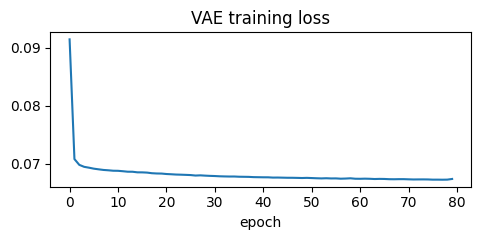

In [6]:
from mlp_vae import MlpVAE

FP_DIM     = obs.shape[1]
LATENT_DIM = 2
HIDDEN     = 64
BETA       = 1e-3
VAE_EPOCHS = 80
VAE_LR     = 1e-3
BATCH_SIZE = 64

vae = MlpVAE(seq_len=FP_DIM, latent_dim=LATENT_DIM, hidden=HIDDEN).to(DEVICE)
opt = torch.optim.Adam(vae.parameters(), lr=VAE_LR)

all_fps = torch.tensor(np.concatenate([obs, next_obs]), dtype=torch.float32)
ds = torch.utils.data.TensorDataset(all_fps)
dl = torch.utils.data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

vae_losses = []
for epoch in range(VAE_EPOCHS):
    epoch_loss = 0.0
    for (x,) in dl:
        x = x.to(DEVICE)
        recon, mu, logvar = vae(x)
        recon_loss = F.mse_loss(recon, x)
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1).mean()
        loss = recon_loss + BETA * kl
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    vae_losses.append(epoch_loss / len(dl))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}  loss={vae_losses[-1]:.5f}")

plt.figure(figsize=(5, 2.5))
plt.plot(vae_losses); plt.title("VAE training loss"); plt.xlabel("epoch"); plt.tight_layout(); plt.show()

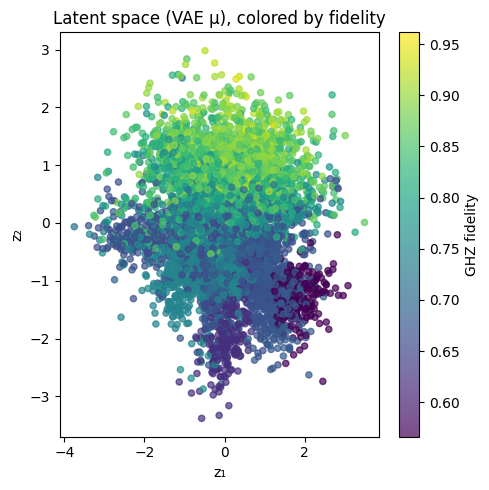

In [7]:
# Encode all fingerprints into latent space
vae.eval()
with torch.no_grad():
    mu_obs  = vae.encode_mu(torch.tensor(obs,      dtype=torch.float32)).numpy()
    mu_next = vae.encode_mu(torch.tensor(next_obs, dtype=torch.float32)).numpy()

plt.figure(figsize=(5, 5))
sc = plt.scatter(mu_obs[:, 0], mu_obs[:, 1], c=fidelities, cmap="viridis", s=20, alpha=0.7)
plt.colorbar(sc, label="GHZ fidelity")
plt.title("Latent space (VAE μ), colored by fidelity")
plt.xlabel("z₁"); plt.ylabel("z₂"); plt.tight_layout(); plt.show()

## Stage 4.5 — Multi-shot Latent Transitions (empirical σ per step)

Run `N_SHOTS_DYN` noisy fingerprint measurements per circuit, encode each shot with the VAE,
and record the **empirical mean and std** of z — this σ(z) will seed the dynamics model's
uncertainty calibration and serves as a proxy for real-device shot noise.


In [ ]:
N_SHOTS_DYN = 8   # noisy fingerprint shots per step for empirical σ

def extract_latent_transitions(plan_or_schedule, n_shots=N_SHOTS_DYN):
    """
    Given a plan_flat (1-D padded array) or a raw schedule (2-D),
    returns a list of dicts {z_t, z_t_std, action, z_next, z_next_std}.
    Encodes n_shots noisy fingerprints per step to estimate empirical σ(z).
    """
    vae.eval()
    if isinstance(plan_or_schedule, np.ndarray) and plan_or_schedule.ndim == 1:
        sched = plan_or_schedule.reshape(PLAN_HORIZON, N_PARAMS)
        mask  = np.any(sched != 0, axis=1)
        idx   = np.where(mask)[0]
        sched = sched[:idx[-1]+1] if len(idx) > 0 else sched[:1]
    else:
        sched = np.array(plan_or_schedule, dtype=np.float32)

    pairs = []
    for t in range(len(sched) - 1):
        qc_t    = bs.build_ansatz_circuit(sched[:t+1])
        qc_next = bs.build_ansatz_circuit(sched[:t+2])
        fps_t    = np.stack([noisy_fingerprint(qc_t)    for _ in range(n_shots)]).astype(np.float32)
        fps_next = np.stack([noisy_fingerprint(qc_next) for _ in range(n_shots)]).astype(np.float32)
        with torch.no_grad():
            mu_t    = vae.encode_mu(torch.tensor(fps_t,    dtype=torch.float32)).numpy()
            mu_next = vae.encode_mu(torch.tensor(fps_next, dtype=torch.float32)).numpy()
        pairs.append({
            "z_t"      : mu_t.mean(axis=0).astype(np.float32),
            "z_t_std"  : mu_t.std(axis=0).astype(np.float32),
            "action"   : sched[t+1].astype(np.float32),
            "z_next"   : mu_next.mean(axis=0).astype(np.float32),
            "z_next_std": mu_next.std(axis=0).astype(np.float32),
        })
    return pairs

# Seed the dynamics transition dataset from all beam-search trajectories
Zt, At, Znxt = [], [], []
for traj in trajectories:
    for p in extract_latent_transitions(np.array(traj["angle_schedule"])):
        Zt.append(p["z_t"])
        At.append(p["action"])
        Znxt.append(p["z_next"])

print(f"Initial latent transition dataset: {len(Zt)} pairs")
print(f"Latent dim={LATENT_DIM}  Action dim={N_PARAMS}  shots/step={N_SHOTS_DYN}")


## Stage 4.6 — Probabilistic Latent Dynamics Model p(z′ | z, a)

MLP outputs (μ, log σ²) for the next latent given the current latent and action.
Trained with **Gaussian NLL** so the predicted variance is calibrated against the
empirical shot-noise collected in Stage 4.5.

`train_dynamics` is reused by the AL loop for incremental fine-tuning.


In [ ]:
class LatentDynamics(nn.Module):
    """Probabilistic latent dynamics:  (z_t, a_t) → (μ_{t+1}, log σ²_{t+1})"""
    def __init__(self, z_dim, a_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + a_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),        nn.SiLU(),
        )
        self.mu_head     = nn.Linear(hidden, z_dim)
        self.logvar_head = nn.Linear(hidden, z_dim)

    def forward(self, z, a):
        h = self.net(torch.cat([z, a], dim=-1))
        return self.mu_head(h), self.logvar_head(h)

def train_dynamics(Zt_list, At_list, Znxt_list, epochs=300, lr=1e-3):
    """(Re)train LatentDynamics from scratch on the current transition lists."""
    Zta  = np.array(Zt_list,   dtype=np.float32)
    Ata  = np.array(At_list,   dtype=np.float32)
    Znxa = np.array(Znxt_list, dtype=np.float32)
    model = LatentDynamics(LATENT_DIM, N_PARAMS).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    ds_   = torch.utils.data.TensorDataset(
                torch.tensor(Zta), torch.tensor(Ata), torch.tensor(Znxa))
    dl_   = torch.utils.data.DataLoader(ds_, batch_size=64, shuffle=True)
    for _ in range(epochs):
        for zb, ab, znb in dl_:
            zb, ab, znb = zb.to(DEVICE), ab.to(DEVICE), znb.to(DEVICE)
            mu_pred, logvar_pred = model(zb, ab)
            inv_var = torch.exp(-logvar_pred)
            loss = ((mu_pred - znb)**2 * inv_var).mean() + 0.5 * logvar_pred.mean()
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    return model

def dyn_predict(z_np, a_np):
    """Returns (mean, variance) arrays of shape (batch, z_dim)."""
    with torch.no_grad():
        mu, logvar = dyn_model(
            torch.tensor(z_np, dtype=torch.float32).to(DEVICE),
            torch.tensor(a_np, dtype=torch.float32).to(DEVICE))
    return mu.cpu().numpy(), np.exp(logvar.cpu().numpy())

print("Training initial latent dynamics model…")
dyn_model = train_dynamics(Zt, At, Znxt)
print(f"Done.  transitions={len(Zt)}  latent_dim={LATENT_DIM}  action_dim={N_PARAMS}")


## Stage 4.7 — Active Querying Helper

`check_and_query_plan` rolls a plan forward in **latent space** using `dyn_model`.
Whenever the model's predicted std exceeds `UNCERTAINTY_THRESHOLD` it stops predicting,
queries the real simulator (oracle), encodes the empirical next-latent, and appends the
new `(z_t, a_t, z_{t+1})` transition to `(Zt, At, Znxt)` for fine-tuning.

This helper is called in **Stage 7** after the AL loop has converged.


In [ ]:
UNCERTAINTY_THRESHOLD = 0.12   # mean predicted σ across latent dims → triggers oracle query

def check_and_query_plan(plan_flat, threshold=UNCERTAINTY_THRESHOLD, n_shots=N_SHOTS_DYN):
    """
    Roll plan_flat forward in latent space using dyn_model.
    At any step where mean predicted σ > threshold:
      - query the real simulator (n_shots fingerprints → empirical z)
      - append the resolved (z_t, a_t, z_next) to Zt / At / Znxt
    Returns (final_z, queried_step_indices).
    """
    global Zt, At, Znxt
    vae.eval()
    sched = plan_flat.reshape(PLAN_HORIZON, N_PARAMS)
    mask  = np.any(sched != 0, axis=1)
    idx   = np.where(mask)[0]
    sched = sched[:idx[-1]+1] if len(idx) > 0 else sched[:1]

    # Initialise latent from first-layer fingerprints
    qc0  = bs.build_ansatz_circuit(sched[:1])
    fps0 = np.stack([noisy_fingerprint(qc0) for _ in range(n_shots)]).astype(np.float32)
    with torch.no_grad():
        z = vae.encode_mu(torch.tensor(fps0, dtype=torch.float32)).numpy().mean(axis=0)

    queried_steps = []
    for t in range(len(sched) - 1):
        a = sched[t + 1].astype(np.float32)
        mu_pred, var_pred = dyn_predict(z[None, :], a[None, :])
        mean_std = float(np.sqrt(var_pred).mean())

        if mean_std > threshold:
            # Uncertainty too high — query real device for this transition
            qc_next  = bs.build_ansatz_circuit(sched[:t + 2])
            fps_next = np.stack([noisy_fingerprint(qc_next) for _ in range(n_shots)]).astype(np.float32)
            with torch.no_grad():
                z_emp = vae.encode_mu(torch.tensor(fps_next, dtype=torch.float32)).numpy()
            z_next = z_emp.mean(axis=0).astype(np.float32)
            # Augment transition dataset
            Zt.append(z.astype(np.float32))
            At.append(a)
            Znxt.append(z_next)
            queried_steps.append(t)
            z = z_next
        else:
            z = mu_pred[0]

    return z, queried_steps

print(f"Active query helper ready.  Uncertainty threshold = {UNCERTAINTY_THRESHOLD}")


## Stage 5 — Initial Fidelity Predictor

Train `g(schedule_flat) → fidelity` on beam-search trajectories + random augmentation.  
This gives a cheap surrogate for the real simulator.  
Stage 6 will iteratively improve it via an **active learning loop**.


In [8]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import Linear, SiLU, Sequential

# ── Constants ─────────────────────────────────────────────────────────────────
MAX_ROUNDS_DATA = max(len(t["angle_schedule"]) for t in trajectories)
N_PARAMS        = bs.N_PARAMS
SCHED_FLAT_DIM  = MAX_ROUNDS_DATA * N_PARAMS

def flat_sched(s, H=MAX_ROUNDS_DATA, P=N_PARAMS):
    """Flatten and zero-pad a schedule array to shape (H*P,)."""
    out  = np.zeros(H * P, dtype=np.float32)
    flat = np.array(s, dtype=np.float32).flatten()
    out[:len(flat)] = flat[:H*P]
    return out

# ── Initial dataset: beam-search prefixes + random augmentation ───────────────
X_data, Y_data = [], []

for traj in trajectories:
    sched = np.array(traj["angle_schedule"])
    for end in range(1, len(sched) + 1):
        X_data.append(flat_sched(sched[:end]))
        qc_ = bs.build_ansatz_circuit(sched[:end])
        sv_ = Statevector.from_instruction(qc_)
        Y_data.append(float(state_fidelity(sv_, GHZ)))

N_AUG = 500   # smaller aug — AL loop will add targeted data later
for _ in range(N_AUG):
    n_rounds   = RNG.integers(1, MAX_ROUNDS_DATA + 1)
    sched_rand = RNG.uniform(-np.pi, np.pi, size=(n_rounds, N_PARAMS)).astype(np.float32)
    X_data.append(flat_sched(sched_rand))
    qc_ = bs.build_ansatz_circuit(sched_rand)
    sv_ = Statevector.from_instruction(qc_)
    Y_data.append(float(state_fidelity(sv_, GHZ)))

X_data = list(X_data)   # kept as lists so AL loop can append cheaply
Y_data = list(Y_data)

print(f"Initial dataset: {len(X_data)} samples")
print(f"Fidelity range : [{min(Y_data):.3f}, {max(Y_data):.3f}]  mean={np.mean(Y_data):.3f}")

# ── Model definition ──────────────────────────────────────────────────────────
class FidelityPredictor(nn.Module):
    def __init__(self, input_dim, hidden=256):
        super().__init__()
        self.net = Sequential(
            Linear(input_dim, hidden), SiLU(),
            Linear(hidden, hidden),    SiLU(),
            Linear(hidden, hidden//2), SiLU(),
            Linear(hidden//2, 1),      nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# ── Training helper (reused by AL loop) ──────────────────────────────────────
FP_EPOCHS = 400

def train_fp(X, Y, epochs=FP_EPOCHS, lr=3e-4, seed=0):
    """Train a fresh FidelityPredictor on arrays/lists X, Y. Returns eval-mode model."""
    torch.manual_seed(seed)
    Xa = np.array(X, dtype=np.float32)
    Ya = np.array(Y, dtype=np.float32)
    model = FidelityPredictor(SCHED_FLAT_DIM).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    ds_   = TensorDataset(torch.tensor(Xa), torch.tensor(Ya))
    dl_   = DataLoader(ds_, batch_size=256, shuffle=True)
    for ep in range(1, epochs + 1):
        for xb, yb in dl_:
            pred = model(xb.to(DEVICE))
            loss = nn.functional.mse_loss(pred, yb.to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    return model

# ── Initial fit ───────────────────────────────────────────────────────────────
print("Training initial predictor…")
fp_model = train_fp(X_data, Y_data)

with torch.no_grad():
    pred0 = fp_model(torch.tensor(np.array(X_data), dtype=torch.float32)).numpy()
corr0 = np.corrcoef(Y_data, pred0)[0, 1]
mae0  = np.abs(np.array(Y_data) - pred0).mean()
print(f"Initial predictor — Pearson r: {corr0:.4f}  MAE: {mae0:.4f}")
print(f"Training data max fidelity   : {max(Y_data):.4f}")


Initial dataset: 7720 samples
Fidelity range : [0.000, 0.962]  mean=0.706
Training initial predictor…
Initial predictor — Pearson r: 0.9984  MAE: 0.0062
Training data max fidelity   : 0.9615
Initial predictor — Pearson r: 0.9984  MAE: 0.0062
Training data max fidelity   : 0.9615


## Stage 6 — Active Inference Loop

Treats the ensemble as a **generative model**. Epistemic uncertainty (ensemble disagreement) is "surprise". The agent reacts to surprise by querying the oracle — seeking understanding before exploiting.

Each iteration:
1. **CEM** scores candidates by `mean - β·std` (LCB) → avoids hallucinated regions
2. **Oracle budget splits into two tracks**:
   - 🟢 **Exploit** (`N_EXPLOIT`): highest predicted fidelity — pragmatic value
   - 🔵 **Curious** (`N_CURIOUS`): highest uncertainty among high-fidelity candidates — epistemic value
3. **Belief update**: retrain ensemble on expanded dataset → `σ` drops in explored regions

The second plot shows mean ensemble `σ` decreasing over iterations — the active inference signature.


In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_ENSEMBLE       = 5      # disagreement across these quantifies "surprise"
BETA_UNCERTAINTY = 1.0    # LCB penalty: score = mean - β·std
N_AL_ITERS       = 15
N_ORACLE_BUDGET  = 20     # real simulator calls per AL iteration
EXPLOIT_FRAC     = 0.5    # fraction → greedy (high predicted fidelity)
                          # 1 - EXPLOIT_FRAC → curious (high uncertainty)
N_PLANS          = 400
N_ELITE          = 40
CEM_ITERS        = 25
PLAN_HORIZON     = MAX_ROUNDS_DATA
SCHED_DIM_CEM    = PLAN_HORIZON * N_PARAMS

N_EXPLOIT = int(N_ORACLE_BUDGET * EXPLOIT_FRAC)
N_CURIOUS = N_ORACLE_BUDGET - N_EXPLOIT

# ── Ensemble helpers ──────────────────────────────────────────────────────────
def train_ensemble(X, Y, n=N_ENSEMBLE, epochs=FP_EPOCHS):
    """Train n independent predictors with different random seeds."""
    return [train_fp(X, Y, epochs=epochs, seed=i) for i in range(n)]

def ensemble_predict(models, plans_np):
    """
    Returns (mean, std) arrays of shape (N_plans,).
    std = epistemic uncertainty = proxy for surprise.
    """
    t = torch.tensor(plans_np, dtype=torch.float32)
    with torch.no_grad():
        preds = torch.stack([m(t) for m in models], dim=0)  # (n_ensemble, N)
    return preds.mean(dim=0).numpy(), preds.std(dim=0).numpy()

# ── CEM with LCB scoring (avoids high-surprise OOD regions) ──────────────────
def run_cem_ai(models, init_mean, init_std):
    """CEM planned under LCB: penalises uncertain regions during search."""
    cem_mean = init_mean.copy()
    cem_std  = init_std.copy()
    for _ in range(CEM_ITERS):
        noise  = RNG.normal(0, 1, size=(N_PLANS, SCHED_DIM_CEM)).astype(np.float32)
        plans  = cem_mean[None] + cem_std[None] * noise
        mu, sigma = ensemble_predict(models, plans)
        scores    = mu - BETA_UNCERTAINTY * sigma          # LCB
        elite_idx = np.argsort(scores)[-N_ELITE:]
        elites    = plans[elite_idx]
        cem_mean  = elites.mean(axis=0)
        cem_std   = elites.std(axis=0) + 1e-3
    # Final sample → return raw mean + std for budget splitting
    noise  = RNG.normal(0, 1, size=(N_PLANS, SCHED_DIM_CEM)).astype(np.float32)
    plans  = cem_mean[None] + cem_std[None] * noise
    mu, sigma = ensemble_predict(models, plans)
    return plans, mu, sigma

# ── Oracle ────────────────────────────────────────────────────────────────────
def oracle(plan_flat):
    sched = plan_flat.reshape(PLAN_HORIZON, N_PARAMS)
    mask  = np.any(sched != 0, axis=1)
    idx   = np.where(mask)[0]
    sched = sched[:idx[-1]+1] if len(idx) > 0 else sched[:1]
    return step_fidelity(sched)

# ── Warm-start & initial ensemble ────────────────────────────────────────────
ws_mean = flat_sched(np.array(best["angle_schedule"])).astype(np.float32)
ws_std  = np.full(SCHED_DIM_CEM, np.pi / 10, dtype=np.float32)

print("Training initial ensemble…")
ensemble = train_ensemble(X_data, Y_data)
print("Done.\n")

# ── Active inference loop ─────────────────────────────────────────────────────
al_history   = []
best_real_fid  = oracle(ws_mean)
best_plan_flat = ws_mean.copy()

print(f"Warm-start true fidelity: {best_real_fid:.4f}")
print(f"{'AL':>3}  {'|data|':>7}  {'|dyn|':>6}  {'mean_μ':>7}  {'mean_σ':>7}  "
      f"{'exploit↑':>9}  {'curious↑':>9}  {'best_ever':>10}")
print("─" * 75)

for al_iter in range(N_AL_ITERS):
    # 1. Plan — LCB keeps CEM inside the known distribution
    plans, mu, sigma = run_cem_ai(ensemble, ws_mean.copy(), ws_std.copy())

    # 2a. Exploitation track: top predicted fidelity (pragmatic value)
    exploit_idx = np.argsort(mu)[-N_EXPLOIT:][::-1]

    # 2b. Epistemic track: among candidates with mu > 0.5, pick highest surprise
    hi_mask = mu > 0.5
    if hi_mask.sum() >= N_CURIOUS:
        pool        = np.where(hi_mask)[0]
        curious_idx = pool[np.argsort(sigma[pool])[-N_CURIOUS:][::-1]]
    else:
        curious_idx = np.argsort(sigma)[-N_CURIOUS:][::-1]   # fallback

    query_idx   = np.unique(np.concatenate([exploit_idx, curious_idx]))
    query_plans = plans[query_idx]

    # 3. Oracle — resolve surprise with real evidence
    true_fids = np.array([oracle(p) for p in query_plans])

    # 4. Add to fidelity dataset
    for p, f in zip(query_plans, true_fids):
        X_data.append(p.astype(np.float32))
        Y_data.append(float(f))

    # 5. Update best
    best_iter = int(np.argmax(true_fids))
    if true_fids[best_iter] > best_real_fid:
        best_real_fid  = true_fids[best_iter]
        best_plan_flat = query_plans[best_iter]
        ws_mean        = best_plan_flat.copy()

    n_exp = len(exploit_idx)
    exploit_best = true_fids[:n_exp].max() if n_exp > 0 else 0.0
    curious_best = true_fids[n_exp:].max() if len(true_fids) > n_exp else 0.0

    # 5b. Augment latent transition dataset from best queried plan + fine-tune dyn_model
    best_q_plan = query_plans[best_iter]
    new_pairs   = extract_latent_transitions(best_q_plan)
    for pair in new_pairs:
        Zt.append(pair["z_t"])
        At.append(pair["action"])
        Znxt.append(pair["z_next"])
    if new_pairs:
        dyn_model = train_dynamics(Zt, At, Znxt, epochs=100, lr=5e-4)

    al_history.append((al_iter+1, len(X_data), len(Zt), mu.mean(), sigma.mean(),
                       exploit_best, curious_best, best_real_fid))
    print(f"{al_iter+1:3d}  {len(X_data):7d}  {len(Zt):6d}  {mu.mean():7.4f}  {sigma.mean():7.4f}  "
          f"{exploit_best:9.4f}  {curious_best:9.4f}  {best_real_fid:10.4f}")

    # 6. Belief update — retrain ensemble; σ drops in explored regions
    ensemble = train_ensemble(X_data, Y_data)

# ── Final outputs ─────────────────────────────────────────────────────────────
best_plan = best_plan_flat.reshape(PLAN_HORIZON, N_PARAMS)
mu_f, sigma_f = ensemble_predict(ensemble,
                    best_plan_flat[None].astype(np.float32))
best_score       = float(mu_f[0])
best_uncertainty = float(sigma_f[0])

print(f"\nFinal dataset size        : {len(X_data)}")
print(f"Final dyn transitions     : {len(Zt)}")
print(f"Max fidelity in data      : {max(Y_data):.4f}")
print(f"Best TRUE fidelity (AL)   : {best_real_fid:.4f}")
print(f"Ensemble μ for best plan  : {best_score:.4f}")
print(f"Ensemble σ for best plan  : {best_uncertainty:.4f}  ← low = confident")

# ── Progress plot ─────────────────────────────────────────────────────────────
iters         = [h[0] for h in al_history]
best_ever_    = [h[7] for h in al_history]
mean_sigma_   = [h[4] for h in al_history]
exploit_curve = [h[5] for h in al_history]
curious_curve = [h[6] for h in al_history]
dyn_sizes     = [h[2] for h in al_history]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

ax1.plot(iters, best_ever_,    "b-o",  ms=5, label="best true fidelity (ever)")
ax1.plot(iters, exploit_curve, "g--s", ms=4, label=f"exploit track best (n={N_EXPLOIT})")
ax1.plot(iters, curious_curve, "r--^", ms=4, label=f"curious track best (n={N_CURIOUS})")
ax1.axhline(best["fidelity"], color="orange", ls=":", lw=1.5,
            label=f"beam search ({best['fidelity']:.3f})")
ax1.set_ylabel("GHZ fidelity"); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=8); ax1.set_title("Active inference — fidelity progress")

ax2.plot(iters, mean_sigma_, "m-o", ms=5, label="mean ensemble σ (surprise)")
ax2.set_ylabel("Epistemic uncertainty σ")
ax2.set_title("Surprise decreasing as beliefs are updated ← active inference signature")
ax2.legend(fontsize=8)

ax3.plot(iters, dyn_sizes, "c-o", ms=5, label="|dyn transitions| (grows with queries)")
ax3.set_ylabel("# latent transitions"); ax3.set_xlabel("AL iteration")
ax3.set_title("Dynamics dataset growing via incremental fine-tuning")
ax3.legend(fontsize=8)

plt.tight_layout(); plt.show()


Training initial ensemble…
Done.

Warm-start true fidelity: 0.9615
 AL   |data|   mean_μ   mean_σ   exploit↑   curious↑   best_ever
─────────────────────────────────────────────────────────────────
Done.

Warm-start true fidelity: 0.9615
 AL   |data|   mean_μ   mean_σ   exploit↑   curious↑   best_ever
─────────────────────────────────────────────────────────────────
  1     7740   1.0000   0.0000     0.7151     0.5060      0.9615
  1     7740   1.0000   0.0000     0.7151     0.5060      0.9615
  2     7755   0.9847   0.0023     0.2336     0.2527      0.9615
  2     7755   0.9847   0.0023     0.2336     0.2527      0.9615
  3     7773   0.9922   0.0016     0.2494     0.2586      0.9615
  3     7773   0.9922   0.0016     0.2494     0.2586      0.9615
  4     7792   0.9851   0.0021     0.5854     0.4805      0.9615
  4     7792   0.9851   0.0021     0.5854     0.4805      0.9615
  5     7811   0.9808   0.0018     0.4968     0.5209      0.9615
  5     7811   0.9808   0.0018     0.4968     

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x105aa8400>>
Traceback (most recent call last):
  File "/Users/krzywdaja/Library/Python/3.9/lib/python/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

## Stage 7 — Decode Best Plan → Quantum Circuit + Evaluate

In [ ]:
# ── Active latent verification before committing to the plan ─────────────────
print("Running active latent verification on best plan…")
final_z, queried = check_and_query_plan(best_plan_flat)

if queried:
    print(f"  Queries triggered at steps: {queried}  →  {len(queried)} new transitions added")
    print(f"  Fine-tuning dynamics model on {len(Zt)} transitions…")
    dyn_model = train_dynamics(Zt, At, Znxt, epochs=150, lr=5e-4)
    # Re-run with updated model to confirm uncertainty resolved
    final_z, queried2 = check_and_query_plan(best_plan_flat)
    print(f"  Remaining uncertain steps after fine-tune: {queried2}")
else:
    print("  No uncertain steps — dynamics model is confident for this plan ✓")

print(f"  Final latent z = {final_z.round(4)}")

# ── Strip trailing all-zero rows (padding) before building circuit ────────────
nonzero_rows = np.any(best_plan != 0, axis=1)
last_nonzero = np.where(nonzero_rows)[0][-1] + 1
trimmed_plan = best_plan[:last_nonzero]
print(f"\nTrimmed plan: {len(trimmed_plan)} active rounds (of {PLAN_HORIZON} padded)")

qc_plan  = bs.build_ansatz_circuit(trimmed_plan)
sv_plan  = Statevector.from_instruction(qc_plan)
fid_plan = state_fidelity(sv_plan, GHZ)

print("=" * 55)
print(f"Beam search fidelity         : {best['fidelity']:.4f}")
print(f"CEM plan fidelity (honest)   : {fid_plan:.4f}   ← no scipy used")
print(f"CEM predicted fidelity       : {best_score:.4f}   ← world-model estimate")
print(f"World-model error            : {abs(fid_plan - best_score):.4f}")
print(f"Active queries (Stage 7)     : {len(queried)} steps re-grounded to simulator")
print("=" * 55)

print("\nCEM-planned circuit:")
print(qc_plan.draw(output="text", fold=-1))


Trimmed plan: 30 active rounds (of 30 padded)
Beam search fidelity         : 0.7508
Beam + scipy fidelity        : 1.0000
CEM plan fidelity (honest)   : 0.0675   ← no scipy used
CEM predicted fidelity       : 1.0000   ← world-model estimate
World-model error            : 0.9325

CEM-planned circuit:
      ┌────────────┐               ┌─────────────┐                                ┌─────────────┐                               ┌─────────────┐                              ┌─────────────┐                               ┌─────────────┐                               ┌─────────────┐                              ┌─────────────┐                              ┌─────────────┐                             ┌────────────┐                              ┌─────────────┐                              ┌─────────────┐                              ┌─────────────┐                              ┌─────────────┐                              ┌─────────────┐                             ┌─────────────┐                 

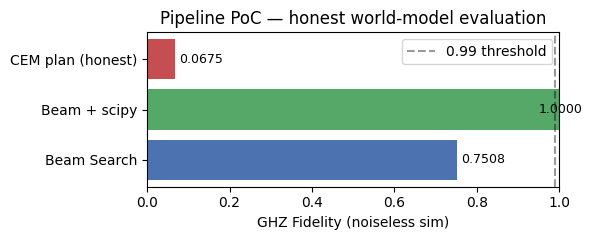


World-model gap: 0.9325  (how much the model still needs to improve)


In [ ]:
# Summary comparison plot
methods = ["Beam Search", "CEM plan (honest)", "CEM predicted"]
fids    = [best["fidelity"], fid_plan, best_score]
colors  = ["#4C72B0", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.barh(methods, fids, color=colors)
ax.set_xlim(0, 1)
ax.axvline(0.99, color="k", linestyle="--", alpha=0.4, label="0.99 threshold")
for bar, f in zip(bars, fids):
    ax.text(min(f + 0.01, 0.95), bar.get_y() + bar.get_height()/2,
            f"{f:.4f}", va="center", fontsize=9)
ax.set_xlabel("GHZ Fidelity (noiseless sim)")
ax.set_title("Pipeline PoC — world model + active latent verification")
ax.legend(); plt.tight_layout(); plt.show()

# Gap analysis
gap = fid_plan - best["fidelity"]
print(f"\nGain over beam search : {gap:+.4f}")
print(f"World-model error     : {abs(fid_plan - best_score):.4f}")
print(f"Active queries (S7)   : {len(queried)} steps re-grounded")
print(f"Total dyn transitions : {len(Zt)}")
